# ASCAD Exploratory Data Analysis

In [2]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Update path if necessary
ascad_database_file = "ATMEGA_AES_v1/ATM_AES_v1_fixed_key/ASCAD_data/ASCAD_databases/ATMega8515_raw_traces.h5"

In [3]:
try:
    in_file = h5py.File(ascad_database_file, "r")
    print("File opened successfully keys: ", list(in_file.keys()))
except Exception as e:
    print("Error opening file:", e)

File opened successfully keys:  ['metadata', 'traces']


In [ ]:
try:
    in_file = h5py.File(ascad_database_file, "r")
    print("File opened successfully keys: ", list(in_file.keys()))
    
    # Access the traces
    traces = in_file["traces"]
    metadata = in_file["metadata"]
    
    # If traces is a dataset, shape[0] or len() will give the number of traces
    num_traces = len(traces)
    print("Number of traces:", num_traces)
    
    # You can also print the full shape of the traces dataset
    print("Shape of traces:", traces.shape)
    print("Shape of metadata:", metadata.shape)

except Exception as e:
    print("Error opening file:", e)


File opened successfully keys:  ['metadata', 'traces']
Number of traces: 60000
Shape of traces: (60000, 100000)


In [5]:
# Load some traces to inspect
X_profiling = np.array(in_file['Profiling_traces/traces'], dtype=np.int8)
Y_profiling = np.array(in_file['Profiling_traces/labels'])

print("Profiling Traces shape:", X_profiling.shape)
print("Profiling Labels shape:", Y_profiling.shape)

Profiling Traces shape: (50000, 700)
Profiling Labels shape: (50000,)


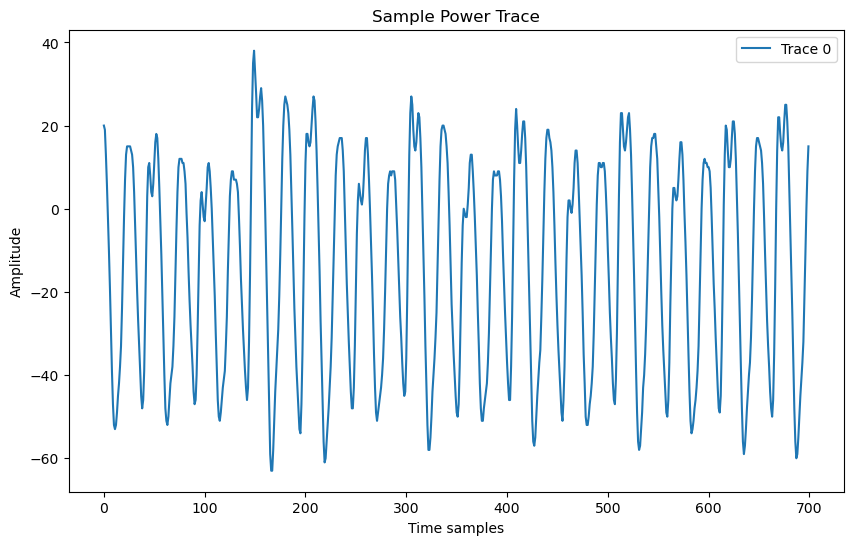

In [6]:
plt.figure(figsize=(10,6))
plt.plot(X_profiling[0], label='Trace 0')
plt.title("Sample Power Trace")
plt.xlabel("Time samples")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

## Label Calculation Check

We will now implement the logic to calculate labels from the metadata (Plaintext and Key) and verify if it matches the ground truth.

In [7]:
# The AES SBox used for label calculation
AES_Sbox = np.array([
    0x63, 0x7C, 0x77, 0x7B, 0xF2, 0x6B, 0x6F, 0xC5, 0x30, 0x01, 0x67, 0x2B, 0xFE, 0xD7, 0xAB, 0x76,
    0xCA, 0x82, 0xC9, 0x7D, 0xFA, 0x59, 0x47, 0xF0, 0xAD, 0xD4, 0xA2, 0xAF, 0x9C, 0xA4, 0x72, 0xC0,
    0xB7, 0xFD, 0x93, 0x26, 0x36, 0x3F, 0xF7, 0xCC, 0x34, 0xA5, 0xE5, 0xF1, 0x71, 0xD8, 0x31, 0x15,
    0x04, 0xC7, 0x23, 0xC3, 0x18, 0x96, 0x05, 0x9A, 0x07, 0x12, 0x80, 0xE2, 0xEB, 0x27, 0xB2, 0x75,
    0x09, 0x83, 0x2C, 0x1A, 0x1B, 0x6E, 0x5A, 0xA0, 0x52, 0x3B, 0xD6, 0xB3, 0x29, 0xE3, 0x2F, 0x84,
    0x53, 0xD1, 0x00, 0xED, 0x20, 0xFC, 0xB1, 0x5B, 0x6A, 0xCB, 0xBE, 0x39, 0x4A, 0x4C, 0x58, 0xCF,
    0xD0, 0xEF, 0xAA, 0xFB, 0x43, 0x4D, 0x33, 0x85, 0x45, 0xF9, 0x02, 0x7F, 0x50, 0x3C, 0x9F, 0xA8,
    0x51, 0xA3, 0x40, 0x8F, 0x92, 0x9D, 0x38, 0xF5, 0xBC, 0xB6, 0xDA, 0x21, 0x10, 0xFF, 0xF3, 0xD2,
    0xCD, 0x0C, 0x13, 0xEC, 0x5F, 0x97, 0x44, 0x17, 0xC4, 0xA7, 0x7E, 0x3D, 0x64, 0x5D, 0x19, 0x73,
    0x60, 0x81, 0x4F, 0xDC, 0x22, 0x2A, 0x90, 0x88, 0x46, 0xEE, 0xB8, 0x14, 0xDE, 0x5E, 0x0B, 0xDB,
    0xE0, 0x32, 0x3A, 0x0A, 0x49, 0x06, 0x24, 0x5C, 0xC2, 0xD3, 0xAC, 0x62, 0x91, 0x95, 0xE4, 0x79,
    0xE7, 0xC8, 0x37, 0x6D, 0x8D, 0xD5, 0x4E, 0xA9, 0x6C, 0x56, 0xF4, 0xEA, 0x65, 0x7A, 0xAE, 0x08,
    0xBA, 0x78, 0x25, 0x2E, 0x1C, 0xA6, 0xB4, 0xC6, 0xE8, 0xDD, 0x74, 0x1F, 0x4B, 0xBD, 0x8B, 0x8A,
    0x70, 0x3E, 0xB5, 0x66, 0x48, 0x03, 0xF6, 0x0E, 0x61, 0x35, 0x57, 0xB9, 0x86, 0xC1, 0x1D, 0x9E,
    0xE1, 0xF8, 0x98, 0x11, 0x69, 0xD9, 0x8E, 0x94, 0x9B, 0x1E, 0x87, 0xE9, 0xCE, 0x55, 0x28, 0xDF,
    0x8C, 0xA1, 0x89, 0x0D, 0xBF, 0xE6, 0x42, 0x68, 0x41, 0x99, 0x2D, 0x0F, 0xB0, 0x54, 0xBB, 0x16
])

def labelize(plaintexts, keys, byte_index):
    return np.uint8(AES_Sbox[plaintexts[:, byte_index] ^ keys[:, byte_index]])

In [8]:
# Load Metadata
metadata_profiling = in_file['Profiling_traces/metadata']
plaintexts = metadata_profiling['plaintext']
keys = metadata_profiling['key']

# --- 1. Calculate Label for Byte 0 (Index 0) ---
target_byte = 0
calculated_labels_byte0 = labelize(plaintexts, keys, target_byte)

print(f"Calculated Labels for Byte {target_byte} (First 10):")
print(calculated_labels_byte0[:10])

Calculated Labels for Byte 0 (First 10):
[179 215  23  16  51 155 179  67  11 145]


In [9]:
# --- 2. Verify Correctness ---
# Since the dataset only contains pre-computed labels for Byte 2 (Index 2),
# we verify our METHOD by calculating Byte 2 and seeing if it matches the file.

target_byte_verification = 2
calculated_labels_byte2 = labelize(plaintexts, keys, target_byte_verification)

# Load actual stored labels
stored_labels = np.array(in_file['Profiling_traces/labels'])

# Compare
are_equal = np.array_equal(calculated_labels_byte2, stored_labels)
print(f"Verification: Do calculated labels for Byte {target_byte_verification} match the dataset file?")
print(f"Result: {are_equal}")

if are_equal:
    print("\nCONCLUSION: Our label calculation formula is CORRECT.")
    print(f"Therefore, the calculated labels for Byte {target_byte} (above) are also correct.")
else:
    print("\nCONCLUSION: Mismatch found. Formula or index incorrect.")

Verification: Do calculated labels for Byte 2 match the dataset file?
Result: True

CONCLUSION: Our label calculation formula is CORRECT.
Therefore, the calculated labels for Byte 0 (above) are also correct.


## Single Sample Inspection

Let's look at a single trace metadata and calculate all its key bytes.

In [10]:
# Select a sample index (e.g., 0)
sample_idx = 0

# Get the metadata for this sample
# metadata_profiling is the dataset
sample_metadata = metadata_profiling[sample_idx]

print(f"--- Metadata for Sample {sample_idx} ---")
# Note: The 'plaintext' and 'key' fields are byte arrays
print(f"Plaintext: {sample_metadata['plaintext']}")
print(f"Key:       {sample_metadata['key']}")
# Masks are also usually in metadata
try:
    print(f"Masks:     {sample_metadata['masks']}")
except:
    pass

print(f"\n--- Calculated Labels for all 16 bytes (Sample {sample_idx}) ---")

p = sample_metadata['plaintext']
k = sample_metadata['key']

# Calculate Sbox[ p ^ k ]
labels_all_bytes = AES_Sbox[p ^ k] 

print(f"Labels per byte (0-15):")
for i, val in enumerate(labels_all_bytes):
    print(f"Byte {i:02d}: {val} (Hex: {val:02X})")

--- Metadata for Sample 0 ---
Plaintext: [  6  65 195  66  25 182 248  19 159 132  97   6  46 137  42  16]
Key:       [ 77 251 224 242 114  33 254  16 167 141  74 220 142  73   4 105]
Masks:     [  7  84  71 171 129 171  90 193 236 131  21 112 185  95 212  55]

--- Calculated Labels for all 16 bytes (Sample 0) ---
Labels per byte (0-15):
Byte 00: 179 (Hex: B3)
Byte 01: 244 (Hex: F4)
Byte 02: 38 (Hex: 26)
Byte 03: 231 (Hex: E7)
Byte 04: 127 (Hex: 7F)
Byte 05: 136 (Hex: 88)
Byte 06: 111 (Hex: 6F)
Byte 07: 123 (Hex: 7B)
Byte 08: 7 (Hex: 07)
Byte 09: 1 (Hex: 01)
Byte 10: 241 (Hex: F1)
Byte 11: 87 (Hex: 57)
Byte 12: 224 (Hex: E0)
Byte 13: 186 (Hex: BA)
Byte 14: 49 (Hex: 31)
Byte 15: 182 (Hex: B6)


## 3rd Byte (Index 2) Verification

We compare the pre-calculated label (Index 2) with our own calculation.

In [11]:

# Select a sample index (e.g., 0)
sample_idx = 2

# Get the metadata for this sample
# metadata_profiling is the dataset
sample_metadata = metadata_profiling[sample_idx]

print(f"--- Metadata for Sample {sample_idx} ---")
# Note: The 'plaintext' and 'key' fields are byte arrays
print(f"Plaintext: {sample_metadata['plaintext']}")
print(f"Key:       {sample_metadata['key']}")
# Masks are also usually in metadata
try:
    print(f"Masks:     {sample_metadata['masks']}")
except:
    pass


# 1. Print the PRE-CALCULATED label stored in the dataset
# Y_profiling corresponds to the standard Index 2 (3rd byte)
stored_label = Y_profiling[sample_idx]
print(f"Stored Label (from file, Index 2) for Sample {sample_idx}: {stored_label} (Hex: {stored_label:02X})")

# 2. Calculate labels for ALL 16 bytes again
metadata = metadata_profiling[sample_idx]
p = metadata['plaintext']
k = metadata['key']
calculated_all = AES_Sbox[p ^ k]

print(f"\nCalculated Labels (All 16 bytes):")
print(calculated_all)

# 3. Highlight comparison
calc_byte2 = calculated_all[sample_idx]
print(f"\nCalculated Label for Byte 2: {calc_byte2} (Hex: {calc_byte2:02X})")

if stored_label == calc_byte2:
    print("MATCH: The stored label matches our calculated label for Byte 2.")
else:
    print("MISMATCH: The stored label does NOT match our calculated label for Byte 2.")

--- Metadata for Sample 2 ---
Plaintext: [202 207 195  33 224 159 105  75 199  25   4  96 135 145 190 130]
Key:       [ 77 251 224 242 114  33 254  16 167 141  74 220 142  73   4 105]
Masks:     [215 205 171  53  41 211  58 129  17 194 183 240 190  48 126 224]
Stored Label (from file, Index 2) for Sample 2: 38 (Hex: 26)

Calculated Labels (All 16 bytes):
[ 23  24  38 102  79 174 136  57 208  34  47 101   1  97 244 233]

Calculated Label for Byte 2: 38 (Hex: 26)
MATCH: The stored label matches our calculated label for Byte 2.


In [1]:
import h5py

# Correct relative path to the raw traces file
filename = "ATMEGA_AES_v1/ATM_AES_v1_fixed_key/ASCAD_data/ASCAD_databases/ATMega8515_raw_traces.h5"

def print_structure(name, obj):
    """Callback to print the name and type of each object."""
    print(f"{name}: {type(obj)}")
    if isinstance(obj, h5py.Dataset):
        print(f"  Shape: {obj.shape}, Dtype: {obj.dtype}")

try:
    with h5py.File(filename, "r") as f:
        print(f"--- Structure of {filename} ---")
        f.visititems(print_structure)
except Exception as e:
    print(f"Error opening {filename}: {e}")

--- Structure of ATMEGA_AES_v1/ATM_AES_v1_fixed_key/ASCAD_data/ASCAD_databases/ATMega8515_raw_traces.h5 ---
metadata: <class 'h5py._hl.dataset.Dataset'>
  Shape: (60000,), Dtype: [('plaintext', 'u1', (16,)), ('ciphertext', 'u1', (16,)), ('key', 'u1', (16,)), ('masks', 'u1', (16,))]
traces: <class 'h5py._hl.dataset.Dataset'>
  Shape: (60000, 100000), Dtype: int8


In [8]:
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

def test_first_10_traces(dataset_path, model_path):
    print(f"Loading dataset from: {dataset_path}")
    try:
        with h5py.File(dataset_path, "r") as in_file:
            # We only need to load the first 10 attacking traces and their true labels
            X_attack = np.array(in_file['Attack_traces/traces'][:10], dtype=np.int8)
            Y_attack = np.array(in_file['Attack_traces/labels'][:10])
    except Exception as e:
        print(f"Error loading dataset: {e}")
        return

    print(f"Loading model from: {model_path}")
    try:
        model = load_model(model_path)
    except Exception as e:
        print(f"Error loading model: {e}")
        return
    
    # Check the model's expected input shape and reshape the data if it is a CNN
    input_layer_shape = model.input_shape
    if len(input_layer_shape) == 3:
        # CNNs require a 3D input: (num_traces, num_features, 1)
        input_data = X_attack.reshape((X_attack.shape[0], X_attack.shape[1], 1))
    elif len(input_layer_shape) == 2:
        # MLPs require a 2D input: (num_traces, num_features)
        input_data = X_attack
    else:
        print(f"Error: model input shape {input_layer_shape} is not currently supported.")
        return
        
    print("Running predictions...")
    predictions = model.predict(input_data)
    
    print("\n--- Results for the first 10 traces ---")
    for i in range(10):
        # The predicted byte is the class with the highest probability
        predicted_byte = np.argmax(predictions[i])
        true_byte = Y_attack[i]
        
        if predicted_byte == true_byte:
            print(f"Trace {i+1:2d}: MATCH    (Predicted: {predicted_byte:3d}, True: {true_byte:3d})")
        else:
            print(f"Trace {i+1:2d}: NO MATCH (Predicted: {predicted_byte:3d}, True: {true_byte:3d})")

# Example usage (update with your actual paths!):
dataset_path = "ATMEGA_AES_v1/ATM_AES_v1_fixed_key/ASCAD_data/ASCAD_databases_byte0_win1/ASCAD_byte0.h5" 
model_path = "ATMEGA_AES_v1/ATM_AES_v1_fixed_key/ASCAD_data/ASCAD_trained_models/cnn_best_byte0_win1_desync0_epochs75_batchsize50.h5"
test_first_10_traces(dataset_path, model_path)


Loading dataset from: ATMEGA_AES_v1/ATM_AES_v1_fixed_key/ASCAD_data/ASCAD_databases_byte0_win1/ASCAD_byte0.h5
Loading model from: ATMEGA_AES_v1/ATM_AES_v1_fixed_key/ASCAD_data/ASCAD_trained_models/cnn_best_byte0_win1_desync0_epochs75_batchsize50.h5
Error loading model: {{function_node __wrapped__AddV2_device_/job:localhost/replica:0/task:0/device:GPU:0}} failed to allocate memory [Op:AddV2] name: 


2026-03-06 22:36:18.431978: W external/local_xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 168.00MiB (rounded to 176160768)requested by op AddV2
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2026-03-06 22:36:18.432026: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1058] BFCAllocator dump for GPU_0_bfc
2026-03-06 22:36:18.432034: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1065] Bin (256): 	Total Chunks: 35, Chunks in use: 34. 8.8KiB allocated for chunks. 8.5KiB in use in bin. 1.2KiB client-requested in use in bin.
2026-03-06 22:36:18.432039: I external/local_xla/xla/tsl/framework/bfc_allocator.cc:1065] Bin (512): 	Total Chunks: 4, Chunks in use: 4. 2.0KiB allocated for chunks. 2.0KiB in use in bin. 2.0KiB client-requested in use in bin.
2026-03-06 22: